### Цели и задачи проекта

провести анализ рынка общественного питания Москвы на основе предоставленных данных для выявления закономерностей
Задачи исследования:
- Выполнить предобработку и очистку данных
- Проанализировать распределение заведений по категориям и административным районам Москвы.
- Изучить отношение сетевых и несетевых заведений в целом и по категориям.
- Исследовать количество посадочных мест: аномальные значения, типичные показатели.
- Оценить распределение рейтингов по категориям и проверить зависимость рейтинга от различных признаков.
- Найти топ-15 самых популярных сетей по количеству заведений и их средние рейтинги с указанием категории.
- Проанализировать изменение среднего чека в зависимости от района и удалённости от центра Москвы.


### Описание данных 
1. rest_info.csv содержит информацию о заведениях общественного питания:
- name — название заведения;
- address — адрес заведения;
- district — административный район, в котором находится заведение, например Центральный административный округ;
- category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- hours — информация о днях и часах работы;
- rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
- seats — количество посадочных мест.
2. rest_price.csv содержит информацию о среднем чеке в заведениях общественного питания:
- price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- avg_bill — строка, которая хранит среднюю стоимость заказа.
- middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
- middle_coffee_cup — число с оценкой одной чашки капучино

### Содержимое проекта

- предобработка и очистка данных обработка пропусков, замена пустых строк, удаление дубликатов, приведение типов, создание признака is_24_7.
- исследовательский анализ по каждому из восьми поставленных вопросов с визуализацией результатов.
- Сформулированы промежуточные выводы по каждому этапу.
- Cоставлен итоговый вывод и даны практические рекомендации для потенциальных инвесторов и предпринимателей.

## 1. Загрузка данных и знакомство с ними


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix 
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Загружаем библиотеки и данные из csv таблиц:
- pandas для работы с таблицами
- matplotlib и seaborn визуализации данных 
- phik для построения матрицы корреляции

In [35]:
print(rest_info.head(), rest_info.info()) 

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   str    
 1   name      8406 non-null   str    
 2   category  8406 non-null   str    
 3   address   8406 non-null   str    
 4   district  8406 non-null   str    
 5   hours     7870 non-null   str    
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), str(6)
memory usage: 2.4 MB
                                 id                  name  category  \
0  0c3e3439a8c64ea5bf6ecd6ca6ae19f0                WoWфли      кафе   
1  045780ada3474c57a2112e505d74b633        Четыре комнаты  ресторан   
2  1070b6b59144425896c65889347fcff6                 Хазри      кафе   
3  03ac7cd772104f65b58b349dc59f03ee  Dormouse Coffee Shop   кофейня   
4  a163aada139c4c7f87b0b1c0b466a50f             Иль Марко  пицц

In [36]:
print(rest_price.head(), rest_price.info()) 

<class 'pandas.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   str    
 1   price              3315 non-null   str    
 2   avg_bill           3816 non-null   str    
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), str(3)
memory usage: 481.7 KB
                                 id          price  \
0  045780ada3474c57a2112e505d74b633  выше среднего   
1  1070b6b59144425896c65889347fcff6        средние   
2  03ac7cd772104f65b58b349dc59f03ee            NaN   
3  a163aada139c4c7f87b0b1c0b466a50f        средние   
4  8a343546b24e4a499ad96eb7d0797a8a        средние   

                        avg_bill  middle_avg_bill  middle_coffee_cup  
0       Средний счёт:1500–1600 ₽           1550.0                NaN  
1         Средний счёт:от 1000 ₽           1000.0   

---

### Промежуточный вывод



- Названия стобцов соответствуют snake-case
- в rest_info 8406 записей, в rest_price 4058 значит информация о ценах есть не для всех нужно учесть при объединении таблиц
- Необходимо обработать данные о часах работы заведения для извлечения необходимых данных
- Большое количество пропусков в данных о количестве мест и ценовой категории

### Подготовка единого датафрейма

- Объединим данные двух таблиц в одну.

In [37]:
df = pd.merge(rest_info, rest_price, on='id', how='outer')

## 2. Предобработка данных


- Преобразуем данные о наличии сети заведений в булевую форму

In [38]:
df['chain'] = df['chain'].astype('bool')

- Проведём обработку пропущенных значений.

In [39]:
for col in df.columns:
    passed_count = df[col].isna().sum()
    print(f"{col} {passed_count} {passed_count/len(df)*100:.3f}%")

id 0 0.000%
name 0 0.000%
category 0 0.000%
address 0 0.000%
district 0 0.000%
hours 536 6.376%
rating 0 0.000%
chain 0 0.000%
seats 3611 42.957%
price 5091 60.564%
avg_bill 4590 54.604%
middle_avg_bill 5257 62.539%
middle_coffee_cup 7871 93.635%


- hour пропуски > 6% можно оставить без изменений, так как будет сформерован отдельный стобец с анализом значений для "ежедневно круглосуточно"
- seats пропуски > 42% может быть связано с тем что в заведении нет сидячих мест или параметр активно изменяется 
- price пропуски > 60% пропуски могут быть связаны со сбоем или завесить от некого параметра лучше заменить на значение 'unknown'
- middle_avg_bill пропуски > 60% столбец заполнен только для записей со строкой «Средний счёт» можно оставить без изменений

In [40]:
df['price'] = df['price'].fillna('unknown')

- Проверим данные на явные и неявные дубликаты.

In [41]:
duplicates_count = df.duplicated().sum()
print(duplicates_count)

0


явные дубликаты не найдены

In [42]:
duplicates_count += df.duplicated().sum()
print(duplicates_count)

0


дубликаты ID также не найдены

- Для нахождения неявных дубликатов приведем имена с адрессом в нижний регистр и удалим символы разделения("/,;_" и пробел) используя replace. После объядиним нормализированное имя и адрес в новой ячейке и по ней найдем совпадения 

In [43]:
df['name_norm'] = df['name'].str.lower().str.strip()
df['address_norm'] = df['address'].str.lower().str.strip()
df['name'] = df['name'].str.replace(r'[,/;_ ]', '', regex=True)
df['name_norm'] = df['name_norm'].str.replace(r'[,/;_ ]', '', regex=True)

df['norm'] = df['name_norm'] + '_' + df['address_norm']
duplicates_count += df.duplicated('norm').sum()
print(duplicates_count)

df = df.drop_duplicates(subset='norm', keep='first')
df.drop(['name_norm', 'address_norm', 'norm'], axis=1, inplace=True)

5


- Создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно:

In [44]:
df['is_24_7'] = ['ежедневно, круглосуточно' in str(h) for h in df['hours']]

---

### Промежуточный вывод


Была проведена предобраткая данных включающая в себя следующие пункты:
- Преобразование данных о наличии сети заведений в булевую форму
- Обработка пропусков значений в столбцах: price(пропуски заменены значением unknown) и seats(пропуски заменены медианной по категории заведения)
- Явные дубликаты не найдены. Неявные дубликаты по столбцам address и name в количестве 5шт. были удалены
- На основе стобца hour создан столбец is_24_7, имеющий значение True для круглосуточных заведений в остальных случаях False.
- Итоговое количество столбцов сократилось на 5 что состовляет менее 0.1% от всех данных

## 3. Исследовательский анализ данных

---

### Задача 1

Исследуем количество объектов общественного питания по каждой категории. 

category
булочная            256
столовая            315
быстрое питание     603
пиццерия            633
бар,паб             765
кофейня            1413
ресторан           2041
кафе               2375
Name: count, dtype: int64


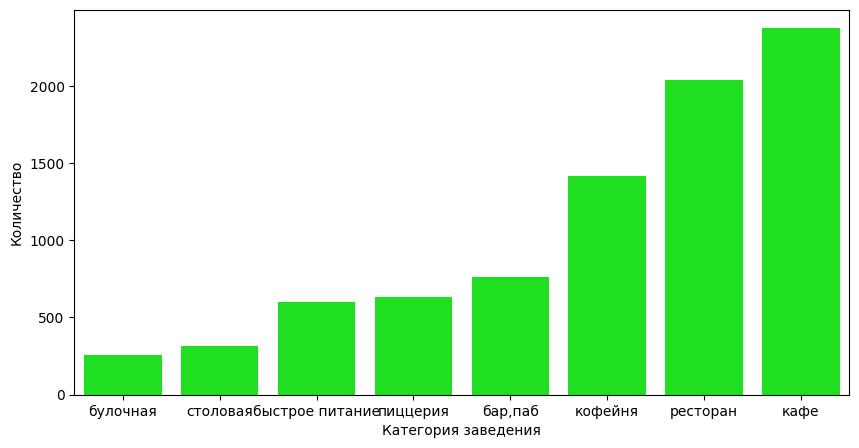

In [45]:
category_counts = df['category'].value_counts().sort_values()
print(category_counts)
plt.figure(figsize=(10, 5))
sns.barplot(x=category_counts.index, y=category_counts.values, color='lime')
plt.xlabel('Категория заведения')
plt.ylabel('Количество')
plt.show()

- Самые популярные: кафе(2375 заведений) и ресторан(2041) они составляют более половины всех заведений.
- Средние по полярности: кофейня(1413), бар,паб(765), пиццерия(633) быстрое питание(603).
- Наименее популярные: столовая(315) и булочная(256).

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

district
Центральный административный округ         2241
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: count, dtype: int64


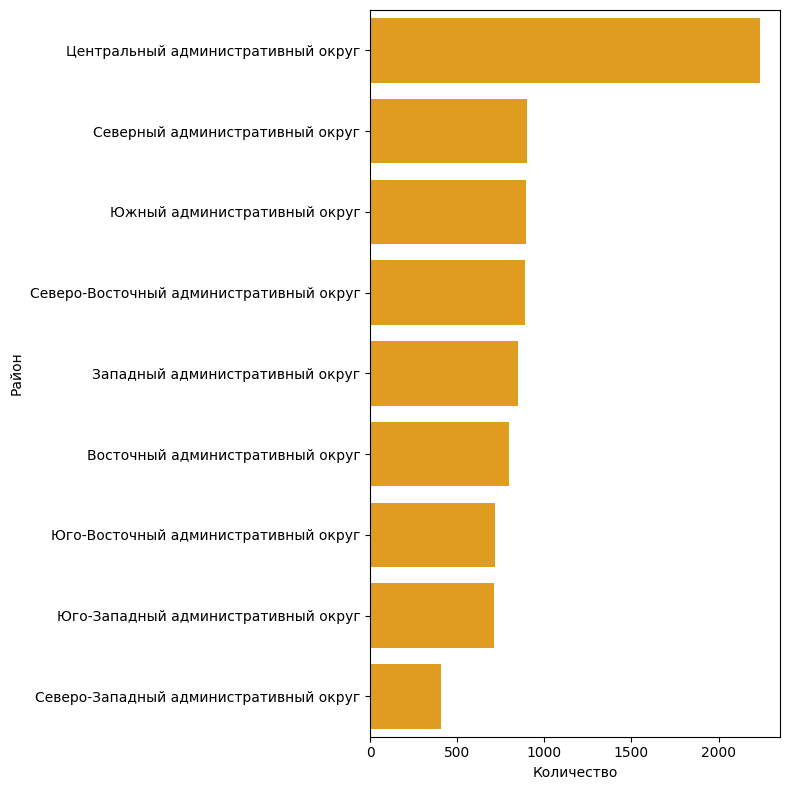

In [46]:
district_counts = df['district'].value_counts().sort_values(ascending=False)
print(district_counts)
plt.figure(figsize=(8, 8))
sns.barplot(x=district_counts.values, y=district_counts.index, color='orange')
plt.xlabel('Количество')
plt.ylabel('Район')
plt.tight_layout()
plt.show()

- Количество заведений в ЦАО(2241) значительно превышает остальные более 25% от общего числа. Причинами могут быть высокая плотность населения, туристическая и деловая активность.
- Остальные округа имеют примерно одинаковое количество заведений – от 700 до 900, кроме Северо-Западного округа, где их заметно меньше (409). 

---
### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

Количество сетевых: 3204
Количество несетевых 5197


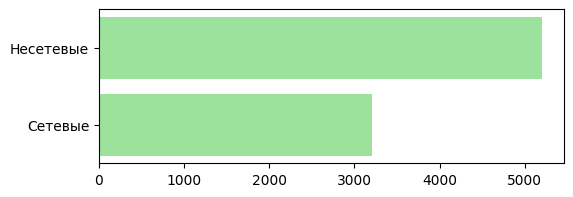

In [47]:
chain_counts = df['chain'].sum()
nochain_count = len(df['chain']) - chain_counts
print("Количество сетевых:", chain_counts)
print("Количество несетевых", nochain_count)
plt.figure(figsize=(6, 2))
sns.barplot(x=[nochain_count, chain_counts], y=[ 'Несетевые', 'Сетевые'], color='lightgreen')
plt.show()

category
булочная                    61.328125%
пиццерия            52.13270142180095%
кофейня            50.955414012738856%
быстрое питание     38.47429519071311%
ресторан            35.71778539931406%
кафе               32.800000000000004%
столовая           27.936507936507937%
бар,паб            22.091503267973856%
Name: chain, dtype: str


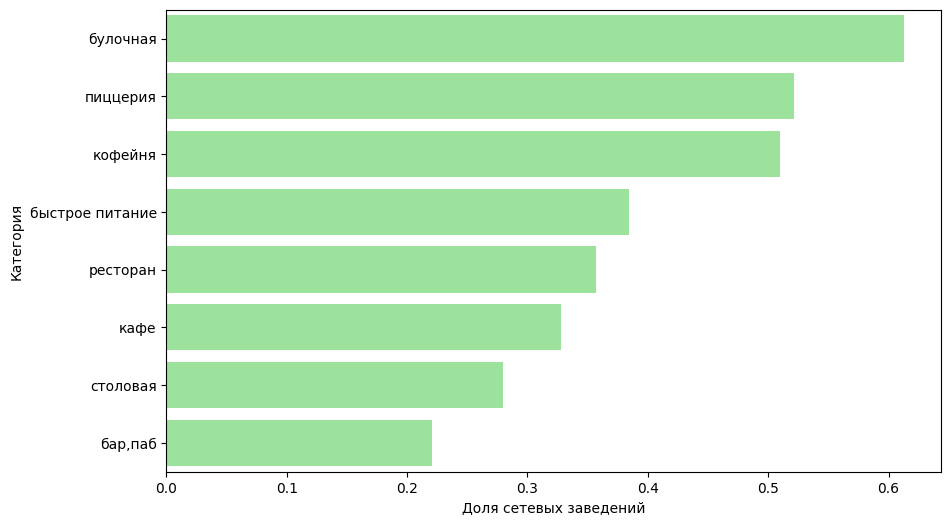

In [48]:
chain_by_category = df.groupby('category')['chain'].mean().sort_values(ascending=False)
print((chain_by_category * 100).astype(str) + '%')

plt.figure(figsize=(10, 6))
sns.barplot(x=chain_by_category.values, y=chain_by_category.index, color='lightgreen')
plt.xlabel('Доля сетевых заведений')
plt.ylabel('Категория')
plt.show()

-  несетевых заведений значительно больше
-  Категории с наибольшей долей несетевых: Булочные 61,3% Пиццерии 52,1% Кофейни 51,0%
-  Категории с наименьшей долей сетевых: Бары, пабы – 22,1% Столовые – 27,9% Кафе – 32,8%

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


In [49]:
print(df['seats'].describe())

count    4791.000000
mean      108.342308
std       122.846815
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64


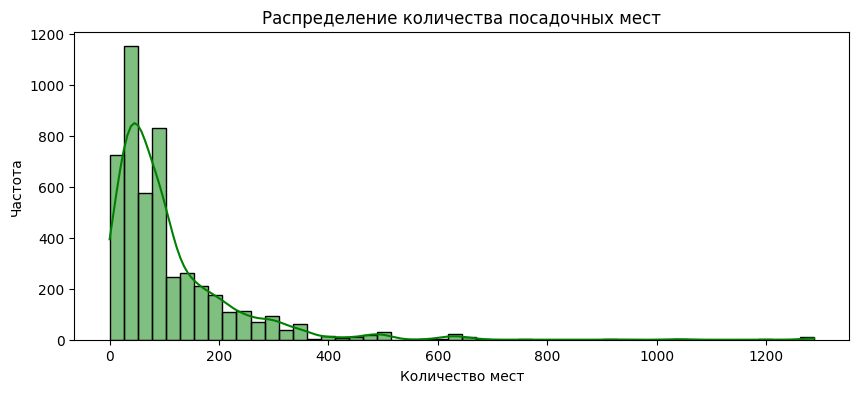

In [50]:
plt.figure(figsize=(10,4))
sns.histplot(df['seats'], bins=50, kde=True, color='green')
plt.title('Распределение количества посадочных мест')
plt.xlabel('Количество мест')
plt.ylabel('Частота')
plt.show()

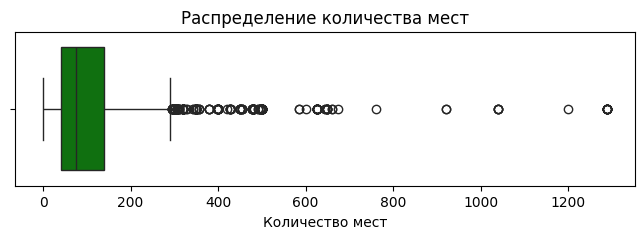

In [51]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['seats'], color='green')
plt.title('Распределение количества мест')
plt.xlabel('Количество мест')
plt.show()

category
ресторан           86.0
бар,паб            82.5
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64


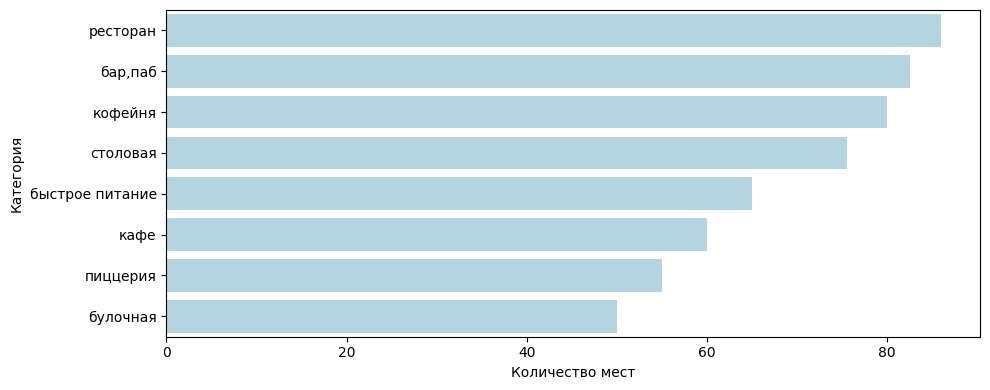

In [52]:
median_seats = df.groupby('category')['seats'].median().sort_values(ascending=False)
print(median_seats)
plt.figure(figsize=(10,4))
sns.barplot(x=median_seats.values, y=median_seats.index, color='lightblue')
plt.xlabel('Количество мест')
plt.ylabel('Категория')
plt.tight_layout()
plt.show()

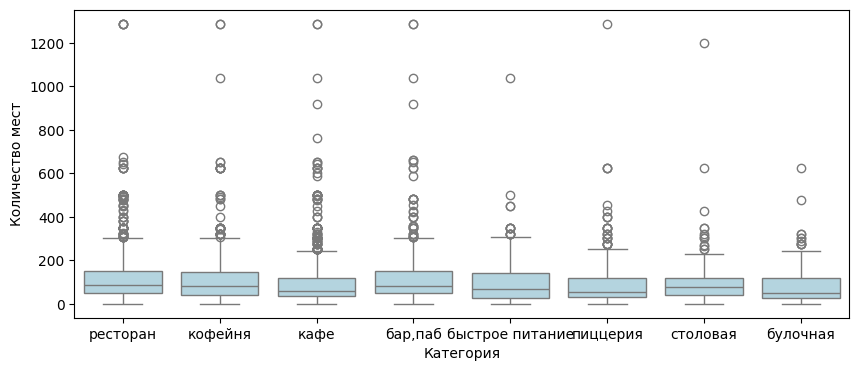

In [53]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='category', y='seats', color='lightblue')
plt.xlabel('Категория')
plt.ylabel('Количество мест')
plt.show()

- На гистограмме можно увидеть длинный правый хвост, это говорит о наличии сильных выбросов в правой части это подтверждает разница между 75 процентилем и максимальным значением 
- Для нахождения количества мест в категории используем медиану так как имеется много выбросов
- Самые маленькие заведения – булочные 50 мест и пиццерии 55. Бары/пабы и рестораны – самые крупные с медианой 82 и 86.
- У большинства категорий есть выбросы.
Больше всего выбросов у ресторанов, столовой, кафе. Это связано с наличием очень крупных заведения. У булочных и пиццерий разброс меньше, хотя есть большие по значению выбросы. 

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

                     mean  median
category                         
бар,паб          4.387712     4.4
булочная         4.268359     4.3
быстрое питание  4.050249     4.2
кафе             4.124211     4.2
кофейня          4.277282     4.3
пиццерия         4.301264     4.3
ресторан         4.290348     4.3
столовая         4.211429     4.3


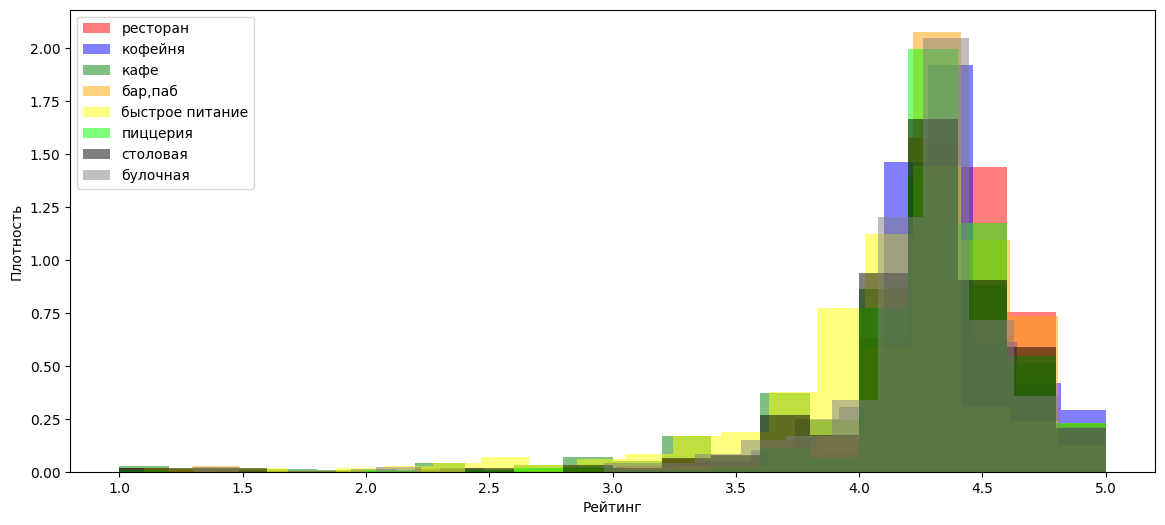

In [54]:
rating_stats = df.groupby('category')['rating'].agg(['mean', 'median'])
print(rating_stats)
plt.figure(figsize=(14,6))
all_categories = df['category'].unique()
colors = ['red', 'blue', 'green', 'orange', 'yellow', 'lime', 'black', 'gray']
for i, cat in enumerate(all_categories):
    curret_category = df[df['category'] == cat]['rating']
    plt.hist(curret_category, bins=20, alpha=0.5, label=cat, density=True, color=colors[i % len(colors)])

plt.xlabel('Рейтинг')
plt.ylabel('Плотность')
plt.legend()
plt.show()

- все категории имеют высокую, примерно одинаковую оценку
- нет большого количества выделяющихся аномальных значений

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

            rating  category  district     chain     seats     price   is_24_7
rating    1.000000  0.189753  0.200731  0.108035  0.000000  0.281334  0.150351
category  0.189753  1.000000  0.174652  0.265520  0.048686  0.329570  0.244843
district  0.200731  0.174652  1.000000  0.064446  0.352401  0.203166  0.076316
chain     0.108035  0.265520  0.064446  1.000000  0.057279  0.088964  0.043310
seats     0.000000  0.048686  0.352401  0.057279  1.000000  0.020049  0.043241
price     0.281334  0.329570  0.203166  0.088964  0.020049  1.000000  0.063727
is_24_7   0.150351  0.244843  0.076316  0.043310  0.043241  0.063727  1.000000


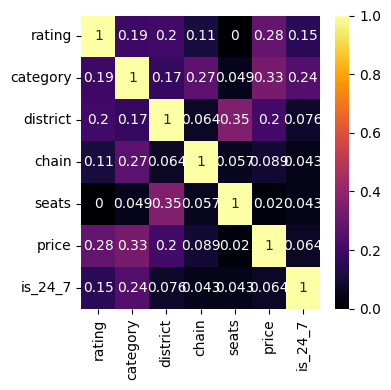

In [55]:
cols = ['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']
phik_matrix = df[cols].phik_matrix(interval_cols=['rating', 'seats'])
print(phik_matrix)
plt.figure(figsize=(4, 4))
sns.heatmap(phik_matrix, annot=True, cmap='inferno')
plt.tight_layout()
plt.show()

In [56]:
print(df.groupby('price')['rating'].agg(['mean', 'count']))

                   mean  count
price                         
unknown        4.166752   5086
высокие        4.436611    478
выше среднего  4.386348    564
низкие         4.173077    156
средние        4.297874   2117


Самая сильная связь рейтинга связана с ценовой категорией. Более дорогие заведения в среднем получают более высокие оценки. Хотя и здесь прослеживается лишь умеренная связь. Остальные признаки показывают слабую связь с рейтингом.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [57]:
with_network = df[df['chain'] == True]
networks = with_network.groupby('name').agg(count=('name', 'count'), avg_rating=('rating', 'mean')).reset_index()
top = networks.sort_values('count', ascending=False).head(15)
categories = []
for name in top['name']:
    cat = df.loc[df['name'] == name, 'category'].iloc[0]
    categories.append(cat)
top['category'] = categories
print(top[['name', 'count', 'avg_rating', 'category']])

                                 name  count  avg_rating         category
743                       Шоколадница    120    4.177500          кофейня
343                     Домино'сПицца     76    4.169737         пиццерия
339                         ДодоПицца     74    4.286486         пиццерия
149                    OnePriceCoffee     71    4.064789          кофейня
757                       ЯндексЛавка     69    3.872464         ресторан
59                              Cofix     65    4.075385          кофейня
169                             Prime     50    4.116000         ресторан
677                        Хинкальная     44    4.322727  быстрое питание
377                          КОФЕПОРТ     42    4.147619          кофейня
430  КулинарнаялавкабратьевКараваевых     39    4.394872             кафе
642                           Теремок     38    4.123684         ресторан
697                           Чайхана     37    3.924324             кафе
40                           CofeFest 

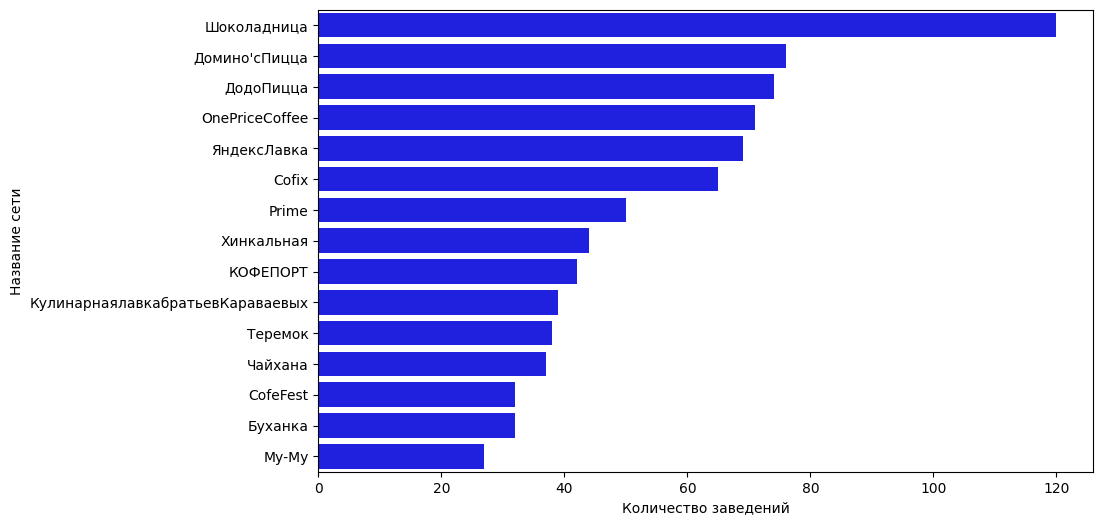

In [58]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top, y='name', x='count', color='blue')
plt.xlabel('Количество заведений')
plt.ylabel('Название сети')
plt.show()

- Лидеры по количеству заведений: Шоколадница» (120) Домино'с Пицца (76) и Додо Пицца (74), обе имеют высокие рейтинги (4,17 и 4,29).

- Кофейни имеют 5 сетей в топ 15 (Шоколадница, OnePriceCoffee, Cofix, КОФЕПОРТ, CofeFest), что означает популярность этой категории. Пиццерии две сети в топ5, обе с высокими рейтингами.

- Рестораны и кафе (Яндекс Лавка, Prime, Теремок, Чайхана, Кулинарная лавка, Му-Му) также имеют много точек, но их количество меньше, чем у лидеров.

- Средние рейтинги: Большинство сетей имеют рейтинг > 4.0, что соответствует общей тенденции.

- Самый высокий средний рейтинг у «Буханка» (4,40) и «Кулинарная лавка братьев Караваевых» (4,39).


---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [59]:
bills = df[df['middle_avg_bill'].notna()]
bills_by_district = bills.groupby('district')['middle_avg_bill'].agg(['mean', 'median', 'count']).sort_values(by='median', ascending=False)
print(bills_by_district)

                                                mean  median  count
district                                                           
Западный административный округ          1053.225490  1000.0    306
Центральный административный округ       1191.057547  1000.0   1060
Северо-Западный административный округ    822.222930   700.0    157
Северный административный округ           927.959627   650.0    322
Юго-Западный административный округ       792.561702   600.0    235
Восточный административный округ          820.626923   575.0    260
Северо-Восточный административный округ   716.611296   500.0    301
Южный административный округ              834.398089   500.0    314
Юго-Восточный административный округ      654.097938   450.0    194


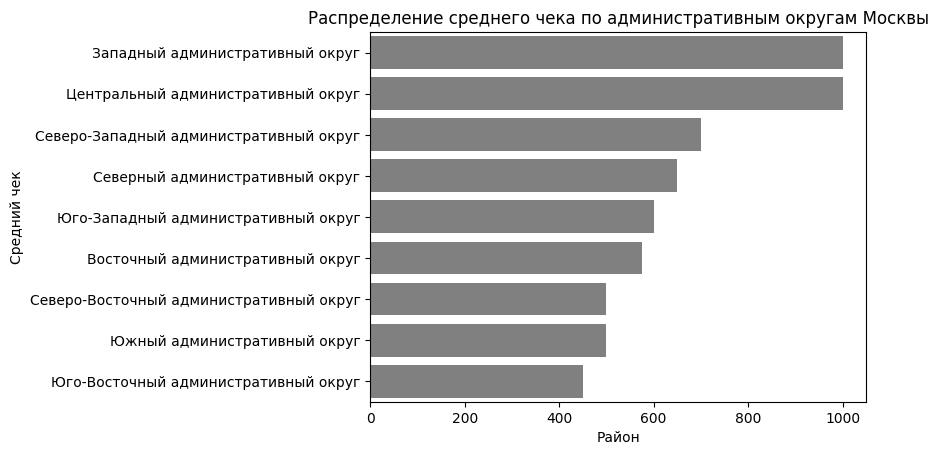

In [60]:
sns.barplot(data=bills_by_district, x='median', y=bills_by_district.index, color='gray')
plt.title('Распределение среднего чека по административным округам Москвы')
plt.xlabel('Район')
plt.ylabel('Средний чек')
plt.show()

Самые большой средний чек в ЦАО и ЗАО разница ещё более ощутима если смотреть на медиану, это значит что в зависемости от удаленности от центра цена чека падает. Так же стоит отметить, что выбросы увеличиваются в некоторых отдаленных райнах 

## 4. Итоговый вывод и рекомендации

В ходе анализа были изучены данные о 8401 заведении общественного питания Москвы. Проведена предобработка данных: обработаны пропуски, устранены дубликаты, приведены типы, создан признак круглосуточной работы. Исследованы: структура по категориям и районам, соотношение сетевых и несетевых заведений, количество посадочных мест, рейтинги и их корреляция с характеристиками заведений, топ популярных сетей и вариация среднего чека в зависимости от района.

Главные выводы
- Наибольшее количество заведений сосредоточено в Центральном административном округе.
- Самые популярные категории кафе (2375) и рестораны (2041).
- Несетевых заведений значительно больше (61,8%).
- Наиболее сетевыми оказались булочные (61,3%), пиццерии (52,1%) и кофейни (51,0%).
- Посадочные места сильные выбросы (до 1288 мест) это крупные рестораны, столовые или ошибки данных.
- Рейтинги все категории имеют стабильно высокие средние рейтинги, различия между ними незначительны.
- Наибольшая (но лишь умеренная) корреляция рейтинга выявлена с ценовой категорией более дорогие заведения оцениваются чуть выше.
- Средние рейтинги популярных сетей находятся в диапазоне 3,87–4,40.
- Наибольшие средние чеки – в ЦАО (1191 руб.) и ЗАО (1053 руб.), минимальные – в ЮВАО (654 руб.).

Рекомендации для заказчика
- Для заведений с высоким средним чеком наиболее востребованы ЦАО и ЗАО.
- ЮВАО, СВАО нужно открывать заведения с низким и средним чеком (столовые, быстрое питание, кофейни) для местных жителей.
- При выборе категории стоит учитывать долю сетевых заведений.
- Рейтинг слабо связан с наблюдаемыми характеристиками, ключевое внимание стоит уделить атмосфере создаваемой в дорогих заведениях.
- Для сетевых проектов наиболее перспективны категории с высокой долей сетей – кофейни, пиццерии, булочные. 
- Количество посадочных мест должно соответствовать категории: для булочных и кофеен оптимально 20–50 мест, для ресторанов 60–90, для столовых 80. 